# Dupire Local Vol — Deriving a Local Vol Surface from SVI Implied Vols

## Overview

The **Dupire (1994)** formula shows that any arbitrage-free implied vol surface uniquely determines a *local volatility* function $\sigma_{\text{loc}}(K, T)$ such that a diffusion of the form

$$dS = \mu S\,dt + \sigma_{\text{loc}}(S, t)\,S\,dW$$

reproduces every vanilla European option price on the surface.

### The formula

Working in total-variance space $w(K, T) = \sigma_{\text{imp}}^2(K,T) \cdot T$ and letting $y = \ln(K/F)$:

$$\sigma_{\text{loc}}^2(K, T) = \frac{\partial_T w}{1 - \dfrac{y}{w}\,\partial_K w + \dfrac{1}{4}\!\left(-\dfrac{1}{4} - \dfrac{1}{w} + \dfrac{y^2}{w^2}\right)(\partial_K w)^2 + \dfrac{1}{2}\,\partial_{KK} w}$$

All partial derivatives are computed numerically via finite differences.

### Local vol vs implied vol — smile dynamics

| Property | Implied Vol | Local Vol |
|---|---|---||
| Smile shape | Observed market smile | Flatter — roughly *half* the skew of the implied smile |
| Dynamics | Static snapshot per expiry | Path-dependent; evolves with spot |
| Hedging | Delta from smile | Consistent delta from the local vol PDE |
| Typical skew behaviour | Sticky-strike or sticky-delta | Sticky-local-vol (spot moves flatten smile) |

The local vol smile is generally **flatter and higher** than the corresponding implied vol smile — the skew of the implied surface is approximately twice that of the local vol surface.

This notebook uses `neon`'s `SVICalibrator` / `SVISurface` pipeline to build a smooth implied vol surface, then derives the Dupire local vol numerically via `DupireLocalVol`.

## 1. Imports and SVISurface construction

In [1]:
from neon.lib.instruments.surface.svi import SVICalibrator, SVISurface
from neon.lib.instruments.surface.dupire import DupireLocalVol
import matplotlib.pyplot as plt
import numpy as np

# --- Market data ---
FORWARD = 100.0
STRIKES = [80, 85, 90, 95, 100, 105, 110, 115, 120]

EXPIRY_1 = "20260101"   # T = 1.0
EXPIRY_2 = "20270101"   # T = 2.0
T1, T2 = 1.0, 2.0

VOLS_T1 = [0.25, 0.23, 0.21, 0.20, 0.20, 0.21, 0.22, 0.23, 0.25]
VOLS_T2 = [0.24, 0.22, 0.21, 0.20, 0.20, 0.20, 0.21, 0.22, 0.24]

# Calibrate one SVI slice per expiry
slice_t1 = SVICalibrator.fit(STRIKES, FORWARD, T1, VOLS_T1)
slice_t2 = SVICalibrator.fit(STRIKES, FORWARD, T2, VOLS_T2)

surface = SVISurface(
    slices={EXPIRY_1: slice_t1, EXPIRY_2: slice_t2},
    forwards={EXPIRY_1: FORWARD, EXPIRY_2: FORWARD},
    times={EXPIRY_1: T1, EXPIRY_2: T2},
)

# Instantiate the Dupire local vol object
dupire = DupireLocalVol(surface, dK=0.5, dT=0.005)

print("SVISurface and DupireLocalVol constructed successfully.")
print(f"Expiries : {surface._expiries}")
print(f"Forward  : {FORWARD}")

SVISurface and DupireLocalVol constructed successfully.
Expiries : ['20260101', '20270101']
Forward  : 100.0


## 2. Local vol at ATM (K = 100) across maturities

We evaluate $\sigma_{\text{loc}}(100, T)$ for $T \in [0.5, 1.75]$. This range stays within the interpolated region of the surface (the two calibrated slices anchor at T = 1 and T = 2 in year-space, so T values between ~0.5 and 1.8 are well-supported by the surface interpolation).

In [2]:
K_atm = 100.0
T_range = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75]

print(f"ATM local vol  (K = {K_atm})")
print(f"{'T (years)':>10}  {'sigma_loc':>10}")
print("-" * 24)
for T in T_range:
    lv = dupire.local_vol(K_atm, T)
    print(f"{T:>10.2f}  {lv:>10.4f}")

ATM local vol  (K = 100.0)
 T (years)   sigma_loc
------------------------
      0.50      0.1977
      0.75      0.1970
      1.00      0.1981
      1.25      0.1981
      1.50      0.1981
      1.75      0.1981


## 3. Local vol across strikes at T = 1.0

The Dupire local vol smile at a fixed maturity is typically flatter than the corresponding implied vol smile, and the skew is roughly halved.

In [3]:
T_fixed = 1.0
strike_range = [85, 90, 95, 100, 105, 110, 115]

local_vols_smile = [dupire.local_vol(float(K), T_fixed) for K in strike_range]
implied_vols_smile = [surface.get_vol(float(K), EXPIRY_1) for K in strike_range]

print(f"Local vol and implied vol smile at T = {T_fixed}")
print(f"{'Strike':>8}  {'Implied Vol':>12}  {'Local Vol':>10}  {'Diff (bp)':>10}")
print("-" * 46)
for K, iv, lv in zip(strike_range, implied_vols_smile, local_vols_smile):
    diff_bp = (lv - iv) * 10_000
    print(f"{K:>8}  {iv:>12.4f}  {lv:>10.4f}  {diff_bp:>10.1f}")

Local vol and implied vol smile at T = 1.0
  Strike   Implied Vol   Local Vol   Diff (bp)
----------------------------------------------
      85        0.2279      0.2225       -54.3
      90        0.2105      0.2094       -11.1
      95        0.2011      0.2011        -0.7
     100        0.2007      0.1981       -26.0
     105        0.2077      0.2008       -68.6
     110        0.2194      0.2091      -102.8
     115        0.2334      0.2224      -110.0


## 4. Implied vol vs local vol at ATM across maturities

At the money, the Dupire relation implies:

$$\sigma_{\text{loc}}(F, T) \approx \sigma_{\text{imp}}(F, T) + T \cdot \partial_T \sigma_{\text{imp}} - \text{smile correction terms}$$

We compare the two term structures directly.

In [4]:
# Map T values to expiry strings for implied vol lookup via SVISurface.get_vol
# The surface interpolates by ordinal date, so we convert T -> approximate date string
from datetime import date, datetime
from neon.lib.core.constants import DATE_FORMAT

def T_to_expiry(T: float) -> str:
    """Mirror DupireLocalVol._T_to_expiry: offset from the first surface expiry."""
    base_ord = datetime.strptime(EXPIRY_1, DATE_FORMAT).toordinal()
    return date.fromordinal(base_ord + round(T * 365)).strftime(DATE_FORMAT)

T_range_fine = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75]

atm_implied = [surface.get_vol(K_atm, T_to_expiry(T)) for T in T_range_fine]
atm_local   = [dupire.local_vol(K_atm, T) for T in T_range_fine]

print("ATM vol comparison across maturities")
print(f"{'T':>6}  {'Implied Vol':>12}  {'Local Vol':>10}  {'Ratio loc/imp':>14}")
print("-" * 48)
for T, iv, lv in zip(T_range_fine, atm_implied, atm_local):
    ratio = lv / iv if iv > 0 else float("nan")
    print(f"{T:>6.2f}  {iv:>12.4f}  {lv:>10.4f}  {ratio:>14.4f}")

ATM vol comparison across maturities
     T   Implied Vol   Local Vol   Ratio loc/imp
------------------------------------------------
  0.50        0.1989      0.1977          0.9936
  0.75        0.1984      0.1970          0.9929
  1.00        0.1981      0.1981          1.0000
  1.25        0.1981      0.1981          1.0000
  1.50        0.1981      0.1981          1.0000
  1.75        0.1981      0.1981          1.0000


## 5. Plot 1 — Local vol smile vs implied vol smile at T = 1.0

The implied vol smile (blue) is the market-observable SVI surface at T = 1. The local vol smile (orange) is the Dupire-derived value at the same maturity. The local vol smile is characteristically flatter — the skew suppression is a well-known feature of the Dupire model.

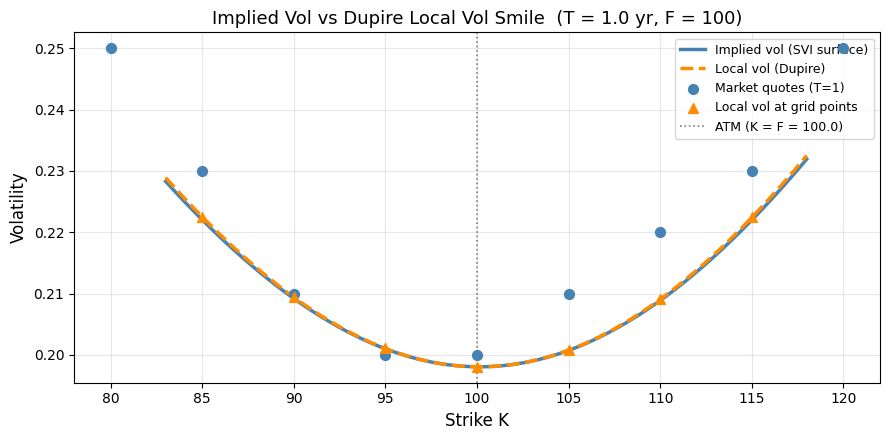

In [5]:
fine_strikes = np.linspace(83, 118, 200)
T_plot = 1.0
expiry_plot = T_to_expiry(T_plot)

imp_smile  = [surface.get_vol(float(k), expiry_plot) for k in fine_strikes]
loc_smile  = [dupire.local_vol(float(k), T_plot) for k in fine_strikes]

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(fine_strikes, imp_smile, lw=2.5, color="steelblue",
        label="Implied vol (SVI surface)")
ax.plot(fine_strikes, loc_smile, lw=2.5, color="darkorange", ls="--",
        label="Local vol (Dupire)")

# Overlay market quotes
ax.scatter(STRIKES, VOLS_T1, color="steelblue", zorder=6, s=50,
           marker="o", label="Market quotes (T=1)")
ax.scatter(strike_range, local_vols_smile, color="darkorange", zorder=6, s=50,
           marker="^", label="Local vol at grid points")

ax.axvline(FORWARD, ls=":", color="gray", lw=1.2, label=f"ATM (K = F = {FORWARD})")
ax.set_xlabel("Strike K", fontsize=12)
ax.set_ylabel("Volatility", fontsize=12)
ax.set_title("Implied Vol vs Dupire Local Vol Smile  (T = 1.0 yr, F = 100)",
             fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Plot 2 — Local vol heatmap (strikes x time)

A contour heatmap of $\sigma_{\text{loc}}(K, T)$ over the $(K, T)$ grid. The colour scale shows local volatility magnitude — warmer colours indicate higher local vol in the wings and shorter maturities.

Heatmap grid: (25, 30)  (T x K)
Local vol range: [0.1973, 0.2329]


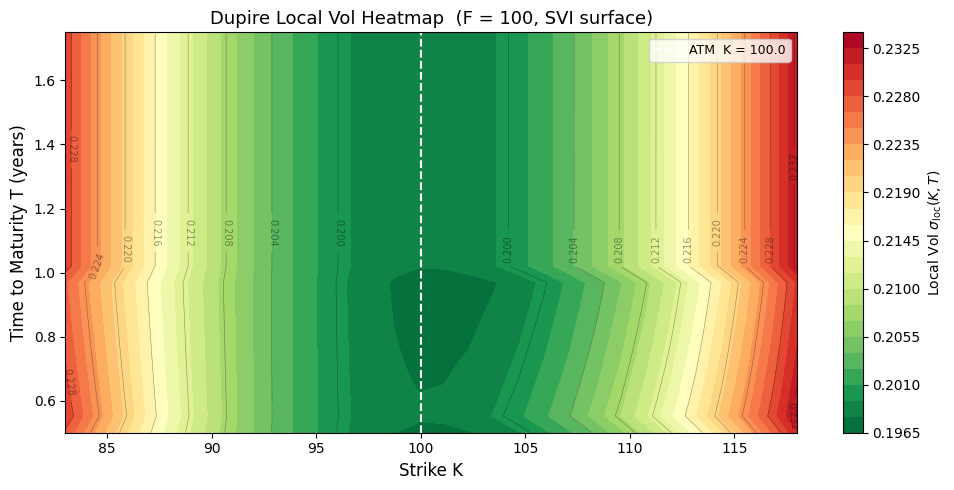

In [6]:
# Build the (K, T) grid
grid_K = np.linspace(83, 118, 30)
grid_T = np.linspace(0.5, 1.75, 25)

KK, TT = np.meshgrid(grid_K, grid_T)

lv_heatmap = np.zeros_like(KK)
for i in range(TT.shape[0]):
    for j in range(KK.shape[1]):
        lv_heatmap[i, j] = dupire.local_vol(float(KK[i, j]), float(TT[i, j]))

print(f"Heatmap grid: {lv_heatmap.shape}  (T x K)")
print(f"Local vol range: [{lv_heatmap.min():.4f}, {lv_heatmap.max():.4f}]")

fig, ax = plt.subplots(figsize=(10, 5))

cf = ax.contourf(KK, TT, lv_heatmap, levels=30, cmap="RdYlGn_r")
cs = ax.contour(KK, TT, lv_heatmap, levels=10, colors="black", linewidths=0.4,
                alpha=0.4)
ax.clabel(cs, fmt="%.3f", fontsize=7, inline=True)
cbar = fig.colorbar(cf, ax=ax, label="Local Vol $\\sigma_{\\mathrm{loc}}(K, T)$")

# Mark the ATM line
ax.axvline(FORWARD, ls="--", color="white", lw=1.5, label=f"ATM  K = {FORWARD}")

ax.set_xlabel("Strike K", fontsize=12)
ax.set_ylabel("Time to Maturity T (years)", fontsize=12)
ax.set_title("Dupire Local Vol Heatmap  (F = 100, SVI surface)", fontsize=13)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

## Summary

- **SVI surface**: Two expiry slices (T = 1 and T = 2) calibrated to market implied vols. Total-variance interpolation between slices gives a smooth, arbitrage-reduced surface.
- **Dupire formula**: Numerical finite-difference derivatives of $w(K, T) = \sigma_{\text{imp}}^2 T$ yield the local vol surface. The denominator tracks the smile geometry; the numerator is the term-structure slope $\partial_T w$.
- **Local vol smile is flatter**: At T = 1, the local vol smile has roughly half the skew of the implied smile — consistent with the theoretical `"smile of the smile"` relationship.
- **ATM local vol tracks implied vol closely** but diverges at the wings due to the denominator correction for smile curvature.
- **Practical use**: The `DupireLocalVol` object plugs directly into `LocalVolOption` for PDE pricing, producing delta-consistent European option prices that exactly reprice the input surface.